In [2]:
import random
import networkx as nx
import torch

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps

from Plots_and_utils.plots import *
import pickle as pkl

import numpy as np
import torch.nn as nn
import math

device = torch.device("cpu")

In [3]:
# DATA
with open("data/2community_dataset/2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community  = pkl.load(f)
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_TOY2community  = pkl.load(f)

# MODELS
with open("Saved_models/6MP_256HDim/2community_GNN_EBM_6MP_15e_300GS.pkl", "rb") as f:
    model_2community_6MP = pkl.load(f)
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_2community_2000GS = pkl.load(f)

In [4]:
def gibbs_ministeps2(adj: torch.Tensor, model: nn.Module, node_feats: torch.Tensor, device: torch.device, mini_steps: int) -> torch.Tensor:
    # run `mini_steps` individual mini-steps: sample a random pair each time
    # its formulation is equal to the standard MH one
    n = adj.shape[0]
    A = adj.clone()
    for _ in range(mini_steps):
        i = random.randrange(0, n)
        j = random.randrange(0, n)
        if i == j:
            continue
        a, b = min(i, j), max(i, j)
        A_prime = A.clone()
        A_prime[a, b] = 1.0 - A_prime[a, b]
        A_prime[b, a] = A_prime[a, b]
        with torch.no_grad():
            fA = model(node_feats.to(device), A.to(device))

            fApr = model(node_feats.to(device), A_prime.to(device))

            T = 1
            p = torch.sigmoid((fA - fApr) / T).item()
            
            if random.random() > p:
                #print(f"Accepted change: with delta {fA - fApr} and prob {p}")
                A = A_prime
    return A

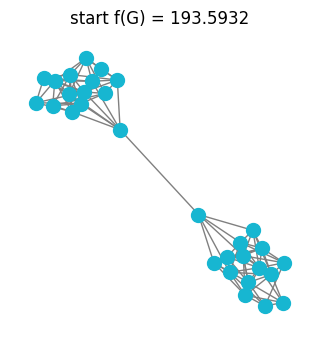

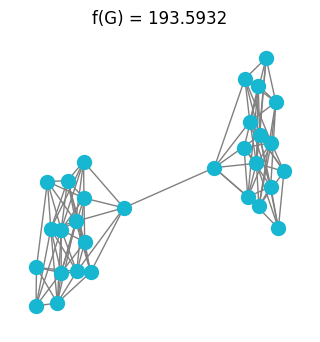

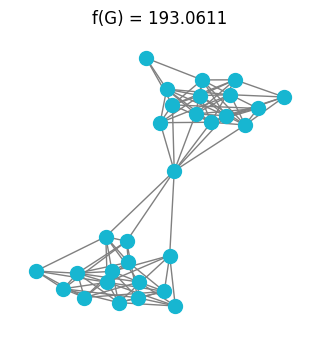

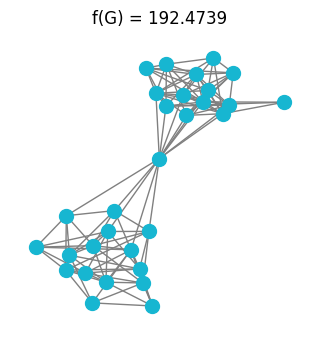

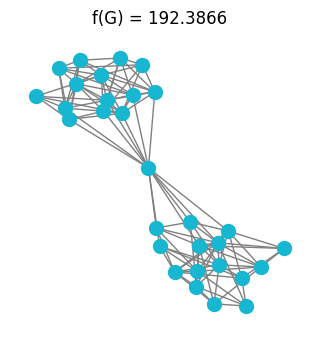

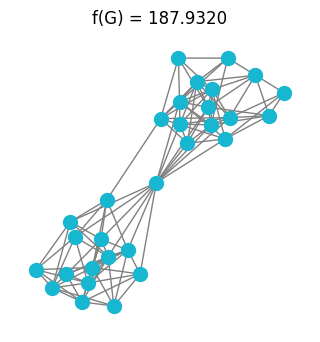

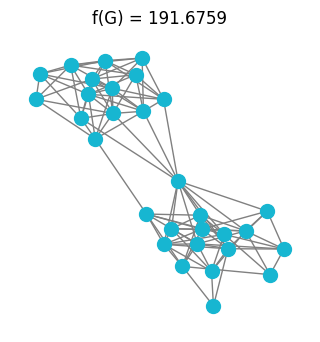

In [5]:
its = 500
plot_every = 100

energies_iterations = []

A, feats = dataset_2community[0]
energy = model_2community_2000GS(feats, A)
plot_graph(A, w = 3, h = 3, node_size=100, title=f"start f(G) = {energy:.4f}")

for i in range(its):
    A = gibbs_ministeps2(A, model_2community_2000GS, feats.to(device), device, mini_steps=1)
    energy = model_2community_2000GS(feats, A)
    if i % plot_every == 0 or i == its - 1:
        plot_graph(A, w = 3, h = 3, node_size=100, title=f"f(G) = {energy:.4f}")
    energies_iterations.append(energy.item())


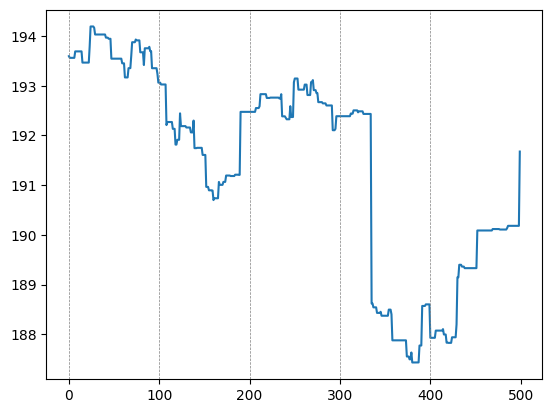

In [6]:
plt.plot(energies_iterations)
for i in range(its//plot_every):
    plt.axvline(i*plot_every, color='gray', linestyle='--', linewidth=0.5)